# Swimming Performance Analysis - Additional Swimmers
This notebook analyzes swimming performance data for additional swimmers using the modular analysis functions.

In [1]:
import sys
sys.path.append('../../')

# Import database and analysis functions
from database import Database
from src.analysis import individual_performance_analysis, event_specific_analysis, comparative_analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Connect to Database and Load Data

In [2]:
# Connect to database
db = Database(file='../../swim_database_2.sqlite3')
print("Database connection established")

Database connection established


In [3]:
# Load discipline_results_ingest table
df = pd.read_sql_query('SELECT * FROM discipline_results_ingest', db.conn)
print(f"Loaded {len(df):,} records from discipline_results_ingest")
print(f"Shape: {df.shape}")
df.head()

Loaded 127,841 records from discipline_results_ingest
Shape: (127841, 31)


,level_0,level_0_production,index,competition_name,competition_link,competition_tabindex,discipline_link,Event number,Event,Category,Minimum,Start Time,Total Entries,Total Participants,results_link,competition_link_check,results_link_check,TotalParticipantsInt,Date,Year,Time,Status,Place,Full name,Year Of Birth,\r\n Club\r\n,Heat,Lane,Results,Points,table_first_row
0,0,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,1,SHIRA BEN-YAISH,2009,Hapoel Emek Yizrael,2,4,00:36.37,334,Direct Finals
1,1,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,2,VIEL MILSHTEIN,2011,Hapoel Emek Yizrael,2,3,00:39.95,252,Direct Finals
2,2,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,3,Mariya Chechotkin,2009,Hapoel Emek Yizrael,2,7,00:41.47,225,Direct Finals
3,3,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,4,SELEN SWAN,2013,Hapoel Lev Hagalil Saknin,1,3,00:47.13,153,Direct Finals
4,4,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,5,LIDA ZELIKMAN,2013,Olimp Swimming Club,1,5,00:48.59,140,Direct Finals


## 2. Convert Results to Seconds

In [4]:
# Import the conversion function
from functions import parse_swim_time_to_seconds

# Apply conversion to Results column
df['result_seconds'] = df['Results'].apply(parse_swim_time_to_seconds)

print(f"Successfully converted: {df['result_seconds'].notna().sum():,} records")
print(f"Conversion rate: {df['result_seconds'].notna().sum() / len(df) * 100:.2f}%")

Successfully converted: 113,568 records
Conversion rate: 88.84%


## 3. Swimmer Analysis

Use the analysis functions to analyze swimmer performance:
- `individual_performance_analysis(df, full_name, event_pattern)` - Track individual progression
- `event_specific_analysis(df, event_pattern, categories, ylim)` - Compare across age groups
- `comparative_analysis(df, full_name, event_pattern, gender, xlim)` - Compare vs same birth year cohort

## 4. Multi-Swimmer Comparative Performance Analysis

In [20]:
# Analyze individual performance for multiple swimmers (no plots)
swimmer_names = [
    'MIAR ZBEDE',
    'ELLA MALUL',
    'Shira Avigdori',
    'MIA ISRALZON',
    'NICOLE FLOMIN',
    'LOREN MEL',
    'SHEINA SAMARA',
    'SOFIA LAPTEVA',
    'LIBI WEINBERG',
    'Akupin Ariel',
    'AYALA SALOMA',
    'AYELET LIPSHITZ',
    'LIOR SHILO'
]

event_pattern = '100.*Backstroke'

# Get data for all swimmers
swimmers_data = {}
for name in swimmer_names:
    data = individual_performance_analysis(df, name, event_pattern, plot=False)
    if len(data) > 0:
        data['Date'] = pd.to_datetime(data['Date'])
        data = data.sort_values('Date')
        swimmers_data[name] = data
        print(f"✓ {name}: {len(data)} races found")
    else:
        print(f"✗ {name}: No data found")



MIAR ZBEDE - 100.*Backstroke Performance Summary:
  Total races: 9
  First recorded time: 88.88s
  Best time: 77.52s
  Latest time: 79.57s
  Improvement from first: 11.36s (12.8%)
✓ MIAR ZBEDE: 9 races found

ELLA MALUL - 100.*Backstroke Performance Summary:
  Total races: 10
  First recorded time: 94.19s
  Best time: 87.40s
  Latest time: 89.54s
  Improvement from first: 6.79s (7.2%)
✓ ELLA MALUL: 10 races found

Shira Avigdori - 100.*Backstroke Performance Summary:
  Total races: 8
  First recorded time: 96.02s
  Best time: 85.66s
  Latest time: 101.45s
  Improvement from first: 10.36s (10.8%)
✓ Shira Avigdori: 8 races found

MIA ISRALZON - 100.*Backstroke Performance Summary:
  Total races: 2
  First recorded time: 96.19s
  Best time: 96.19s
  Latest time: nans
  Improvement from first: 0.00s (0.0%)
✓ MIA ISRALZON: 2 races found
✓ NICOLE FLOMIN: 1 races found

LOREN MEL - 100.*Backstroke Performance Summary:
  Total races: 6
  First recorded time: 97.79s
  Best time: 79.08s
  Lates

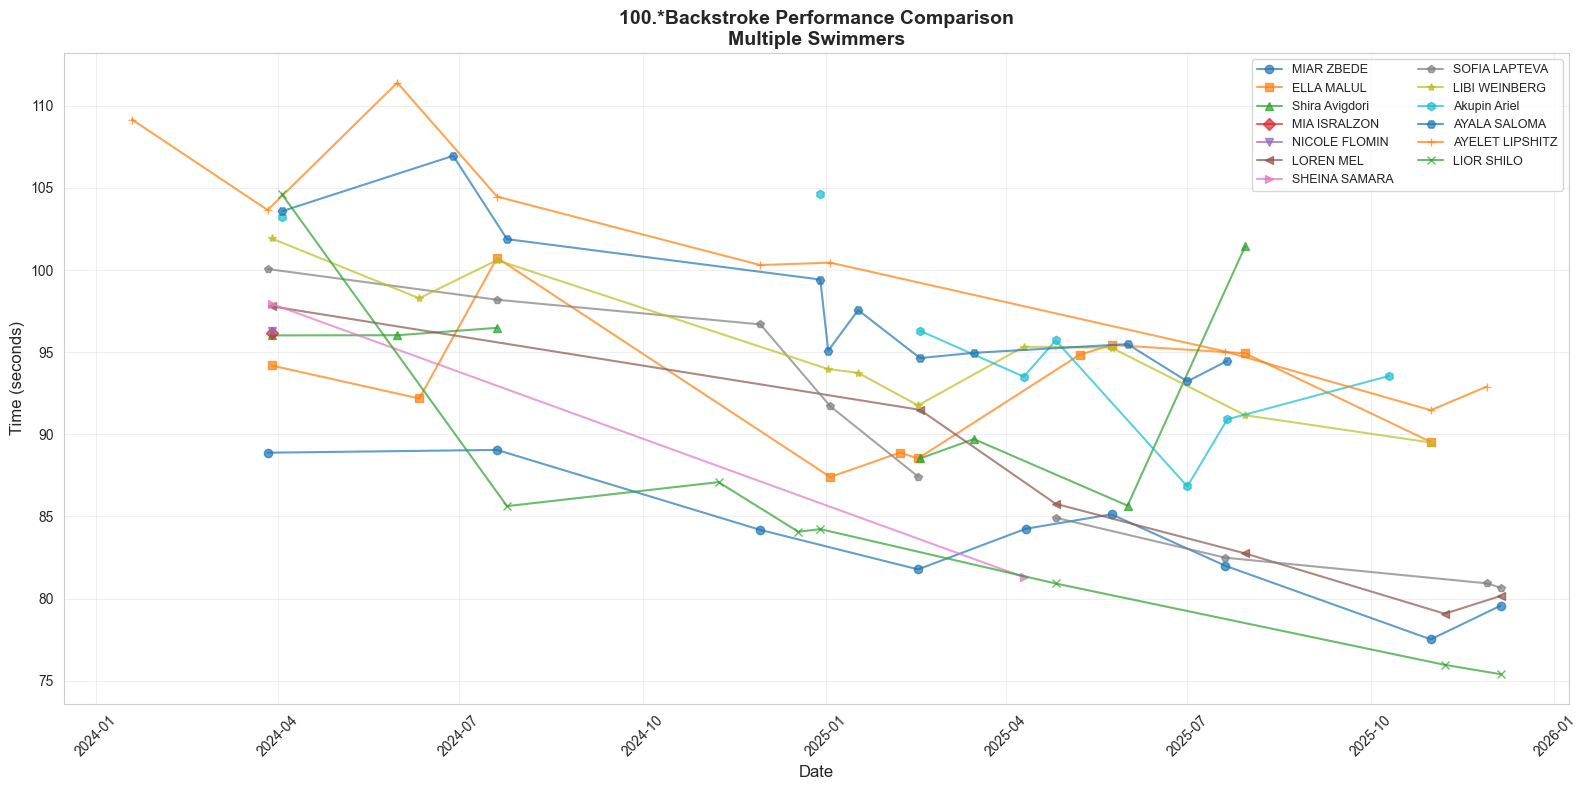


Performance Comparison Summary - 100.*Backstroke

MIAR ZBEDE:
  Best time: 77.52s
  Latest time: 79.57s
  Total races: 9
  Improvement from first: 11.36s (12.8%)

ELLA MALUL:
  Best time: 87.40s
  Latest time: 89.54s
  Total races: 10
  Improvement from first: 6.79s (7.2%)

Shira Avigdori:
  Best time: 85.66s
  Latest time: 101.45s
  Total races: 8
  Improvement from first: 10.36s (10.8%)

MIA ISRALZON:
  Best time: 96.19s
  Latest time: nans
  Total races: 2
  Improvement from first: 0.00s (0.0%)

NICOLE FLOMIN:
  Best time: 96.29s
  Latest time: 96.29s
  Total races: 1
  Improvement from first: 0.00s (0.0%)

LOREN MEL:
  Best time: 79.08s
  Latest time: 80.16s
  Total races: 6
  Improvement from first: 18.71s (19.1%)

SHEINA SAMARA:
  Best time: 81.31s
  Latest time: 81.31s
  Total races: 2
  Improvement from first: 16.63s (17.0%)

SOFIA LAPTEVA:
  Best time: 80.67s
  Latest time: 80.67s
  Total races: 11
  Improvement from first: nans (nan%)

LIBI WEINBERG:
  Best time: 89.50s
  La

In [22]:
# Create combined plot comparing all swimmers
plt.figure(figsize=(16, 8))

# Define markers for variety
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x']

# Plot each swimmer with a different marker
for i, (name, data) in enumerate(swimmers_data.items()):
    marker = markers[i % len(markers)]
    plt.plot(data['Date'], data['result_seconds'], 
             marker=marker, linestyle='-', linewidth=1.5, markersize=6, 
             label=name, alpha=0.7)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.title(f'{event_pattern} Performance Comparison\nMultiple Swimmers', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=9, loc='best', ncol=2)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print comprehensive comparison summary
print(f"\n{'='*80}")
print(f"Performance Comparison Summary - {event_pattern}")
print(f"{'='*80}")

for name, data in swimmers_data.items():
    print(f"\n{name}:")
    print(f"  Best time: {data['result_seconds'].min():.2f}s")
    print(f"  Latest time: {data['result_seconds'].iloc[-1]:.2f}s")
    print(f"  Total races: {len(data)}")
    improvement = data['result_seconds'].iloc[0] - data['result_seconds'].min()
    improvement_pct = (improvement / data['result_seconds'].iloc[0]) * 100
    print(f"  Improvement from first: {improvement:.2f}s ({improvement_pct:.1f}%)")

# Compare best times
best_times = {name: data['result_seconds'].min() for name, data in swimmers_data.items()}

if len(best_times) > 1:
    print(f"\n{'='*80}")
    print(f"Best Time Rankings:")
    sorted_swimmers = sorted(best_times.items(), key=lambda x: x[1])
    for i, (name, time) in enumerate(sorted_swimmers, 1):
        print(f"  {i:2d}. {name:25s} {time:6.2f}s")
    
    # Show time gaps
    print(f"\n{'='*80}")
    print(f"Time Gap Analysis:")
    print(f"  Fastest: {sorted_swimmers[0][0]} - {sorted_swimmers[0][1]:.2f}s")
    print(f"  Slowest: {sorted_swimmers[-1][0]} - {sorted_swimmers[-1][1]:.2f}s")
    print(f"  Gap: {sorted_swimmers[-1][1] - sorted_swimmers[0][1]:.2f}s")
    print(f"{'='*80}")
